In [1]:
import torch
import numpy as np
from sklearn.cluster import AgglomerativeClustering
import umap
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx
import community as community_louvain
import pandas as pd
import seaborn as sns
from scipy.spatial.distance import pdist, squareform

gene_embed = torch.load('gene_embedding_dict.pt')
genes = sorted(gene_embed.keys())  
X = np.stack([gene_embed[g] for g in genes]) 

/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


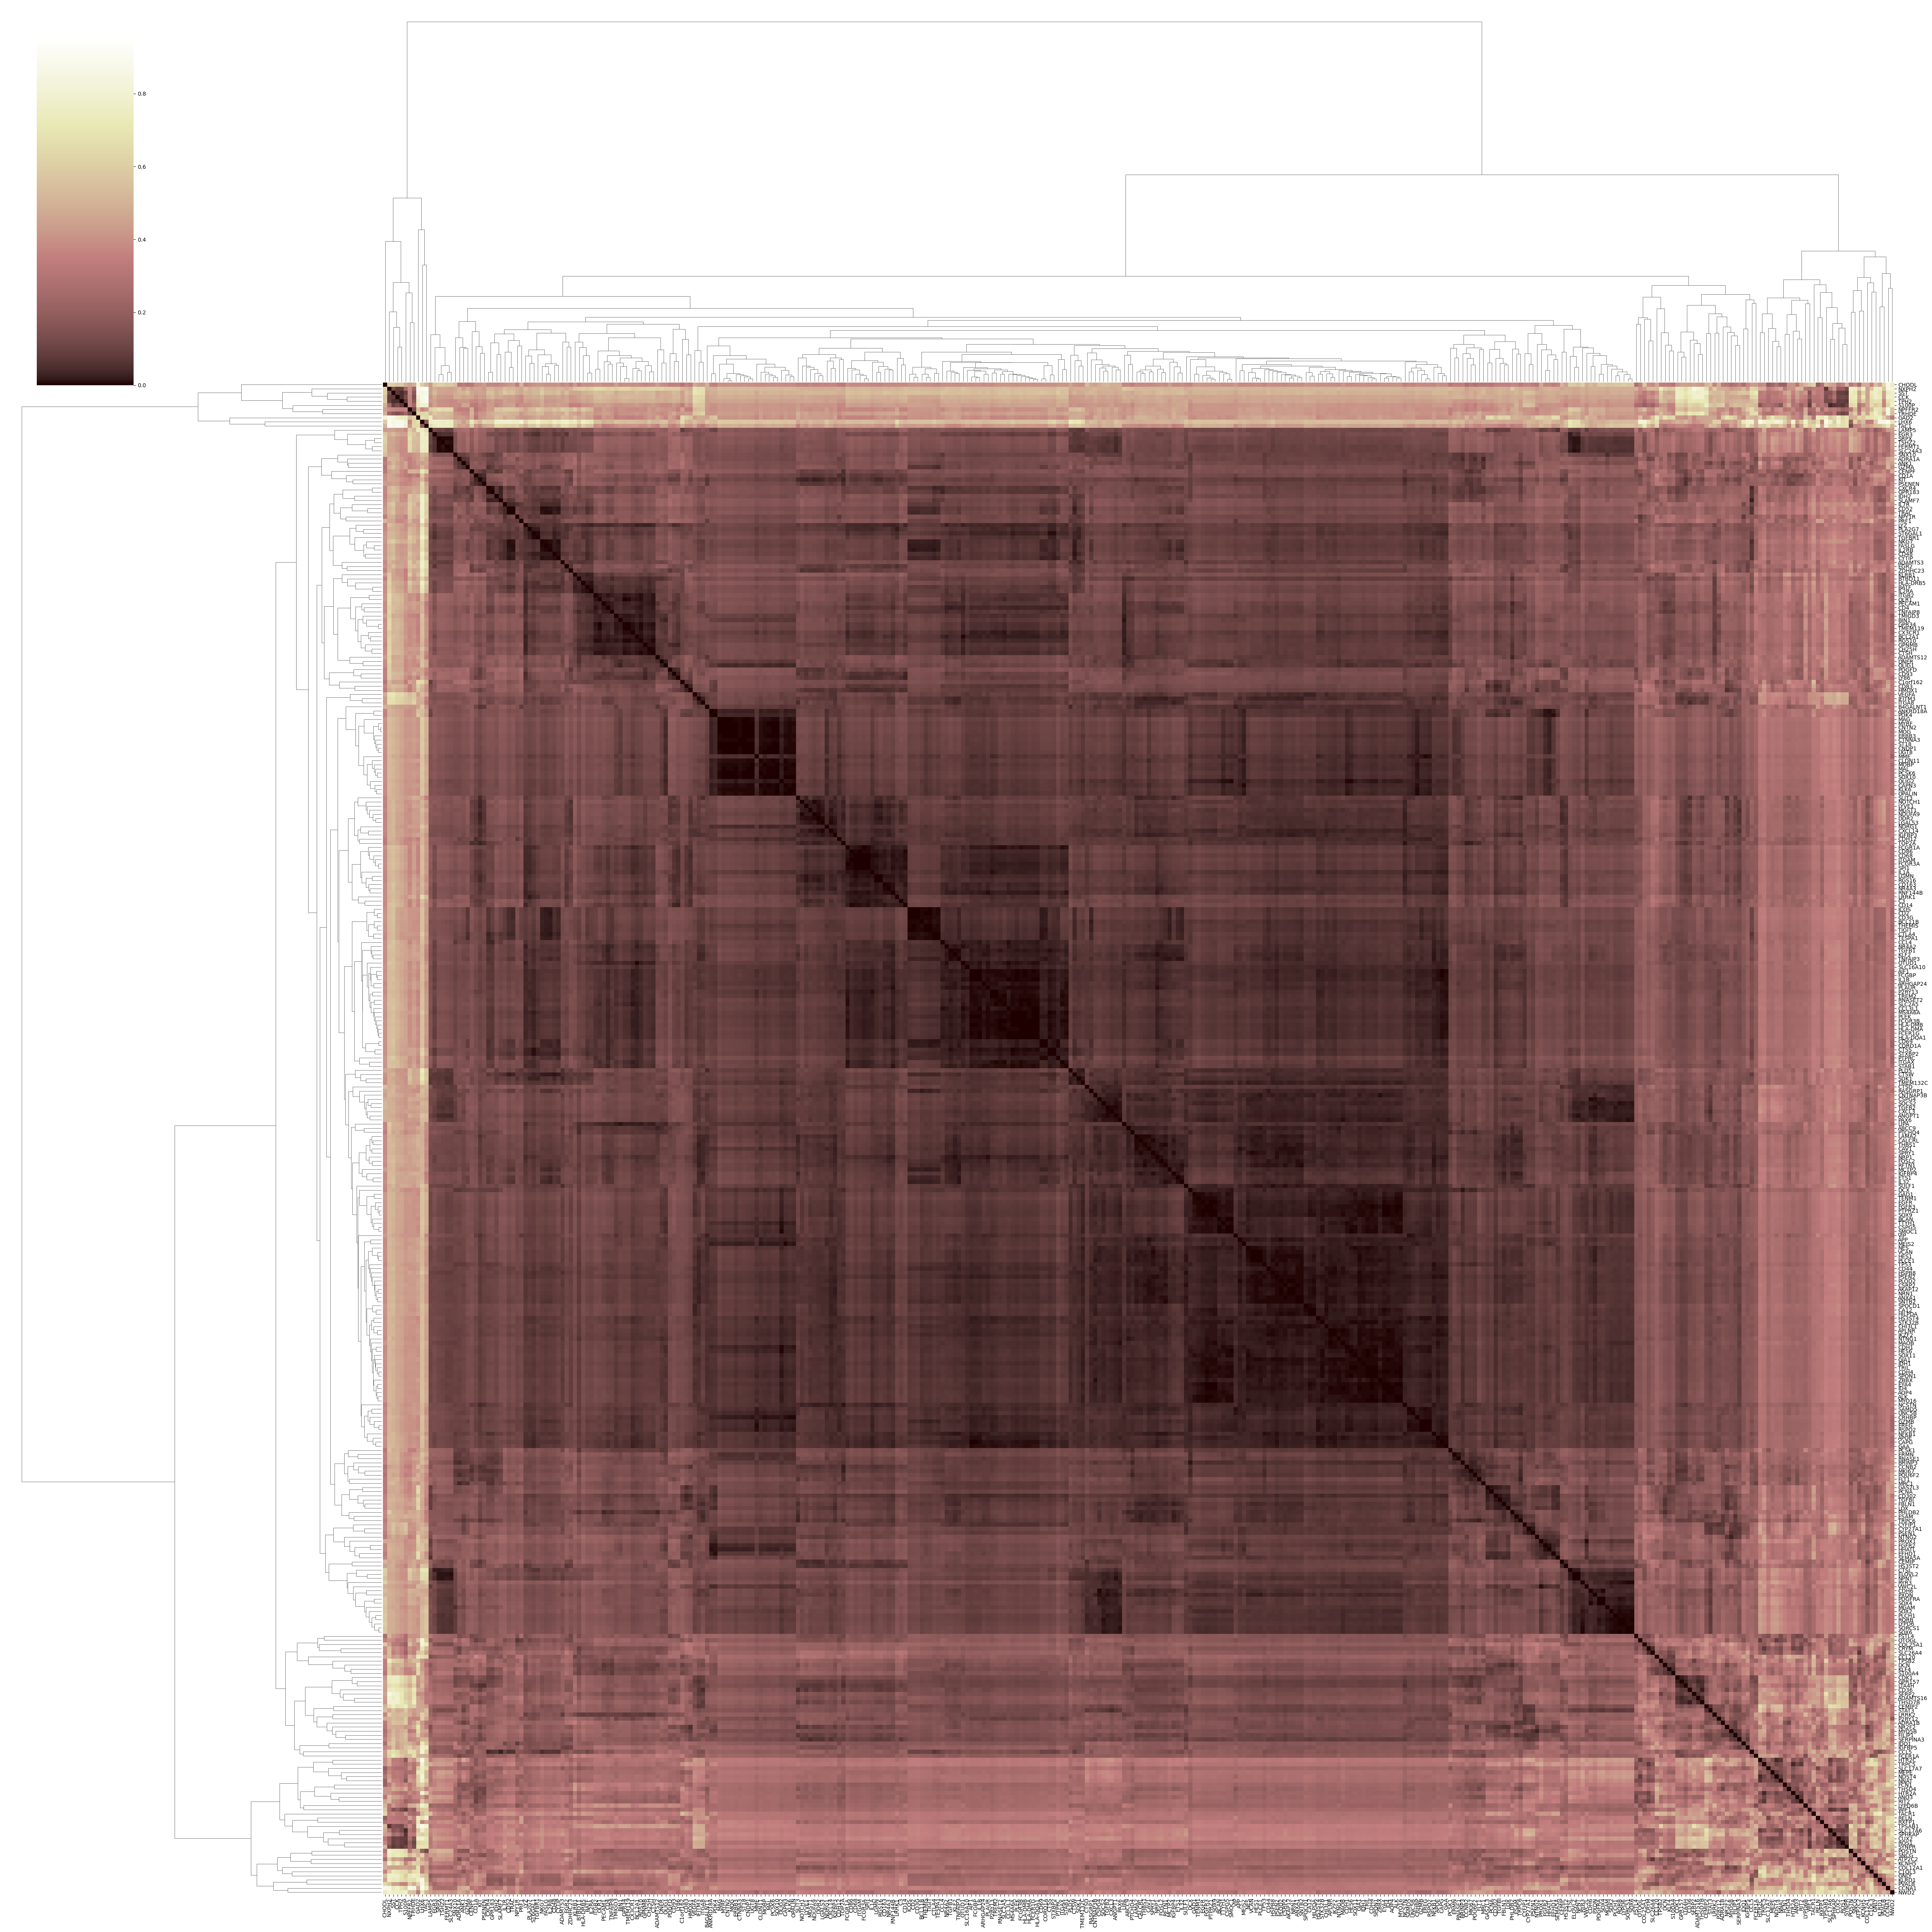

In [27]:
# without scRNA-seq, user can perform a routine clustering 
# and generate an unsupervised clustering (with decent quality)
# for each gene we have 2*N features where N is the number of clusters
# and 2 is logFC and p-value

pairwise_cosine_dist = squareform(pdist(X, metric='cosine'))  
df_distance = pd.DataFrame(pairwise_cosine_dist, index=genes, columns=genes)

# 
sns.clustermap(
    df_distance,
    method='average',    
    metric='euclidean',  
    cmap='pink',
    figsize=(50, 50),
    xticklabels=True,
    yticklabels=True
)
plt.savefig('gene_cosine_distance_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()

/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,
/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/Users/lyuan13/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:530: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage = hierarchy.linkage(self.array, method=self.method,


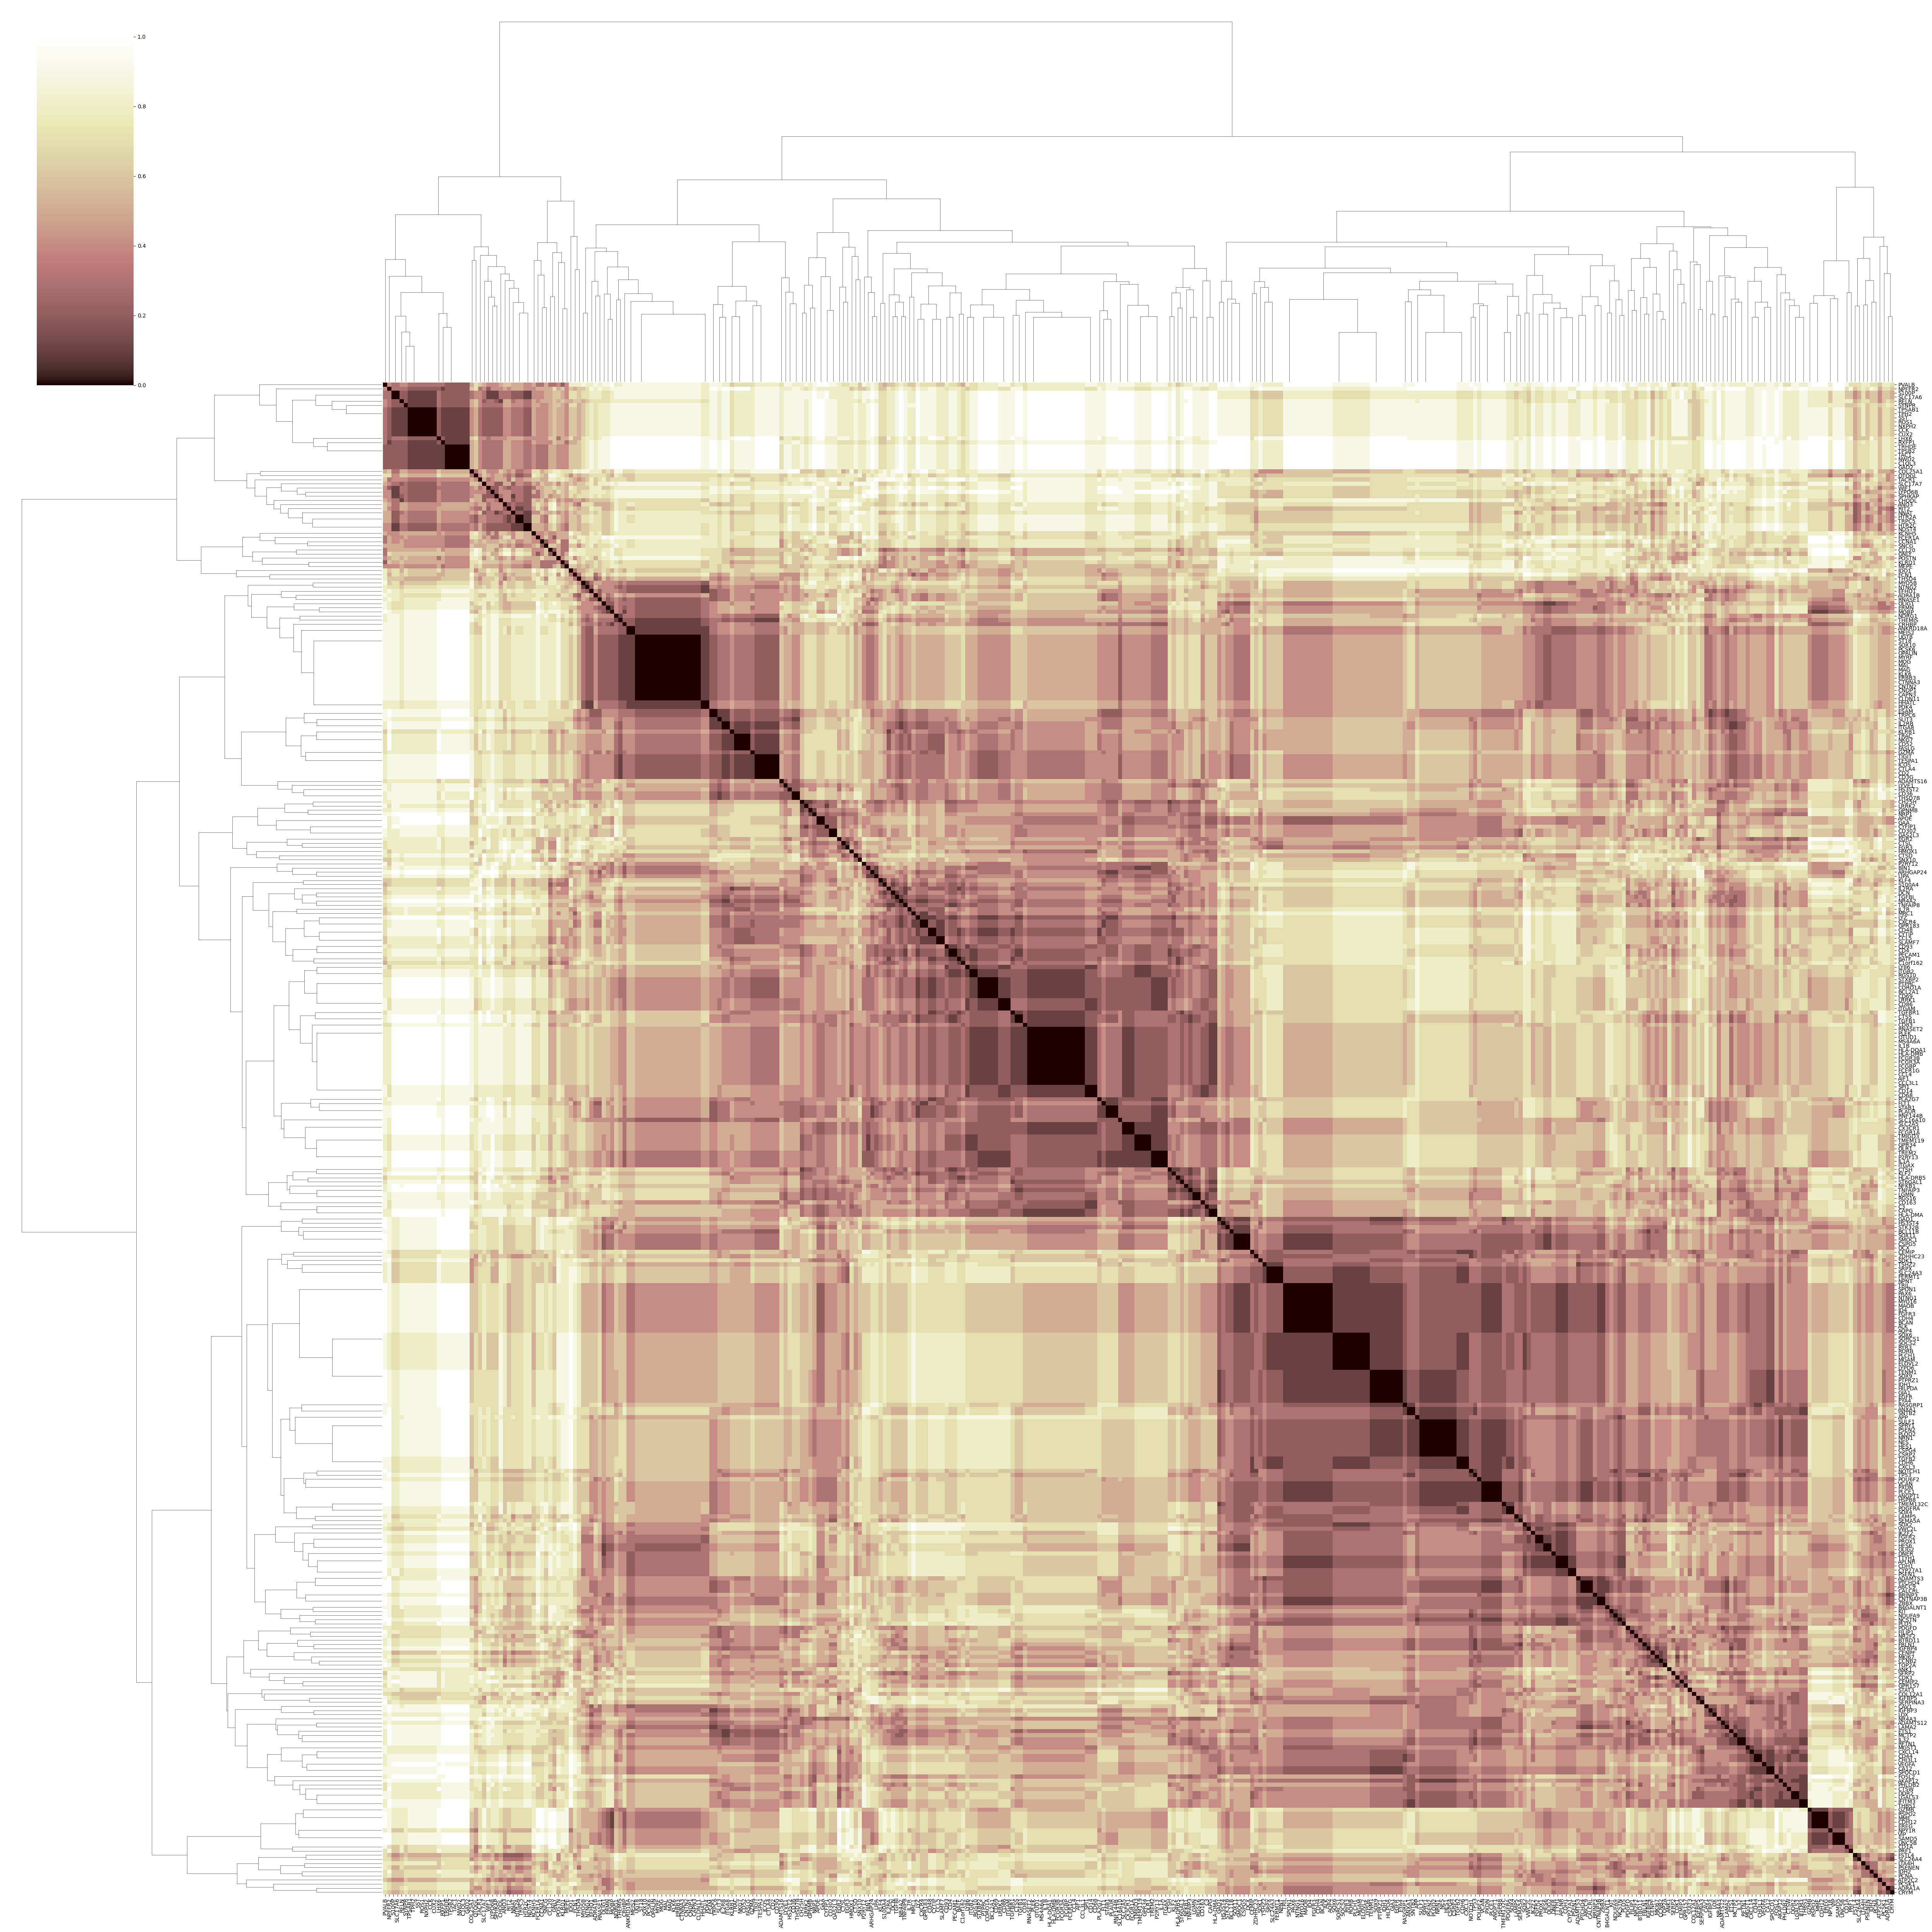

In [32]:
# what if we binarize the logFC based on the p value?
# if p value > 4 and logFC > 0 then set logFC as 1
# if p value > 4 and logFC < 0 then set logFC as -1
# if p value < 4 set logFC as 0

X_raw = X.copy()
X_binarized = np.zeros((X_raw.shape[0], 10)) 

for i in range(10):  # clusters 1 to 10
    logfc = X_raw[:, i*2]      # logFC
    logp  = X_raw[:, i*2 + 1]  # -log10(p)

    # Set based on significance
    mask_significant = logp > 4

    binarized = np.zeros_like(logfc)
    binarized[mask_significant & (logfc > 0)] = 1
    binarized[mask_significant & (logfc < 0)] = -1

    X_binarized[:, i] = binarized
    
pairwise_hamming_dist = squareform(pdist(X_binarized, metric='hamming'))
df_hamming = pd.DataFrame(pairwise_hamming_dist, index=genes, columns=genes)
sns.clustermap(
    df_hamming,
    method='average',
    metric='euclidean',  
    cmap='pink',         
    figsize=(50, 50),
    xticklabels=True,
    yticklabels=True
)
plt.savefig('gene_hamming_distance_binarized_logFC_10D_heatmap.png', dpi=600, bbox_inches='tight')
plt.show()